# Занятие 4. Очистка данных и визуализация


---
# Часть I. Качество данных

---
## 1. Почему качество данных важно

В индустрии принято говорить: **«garbage in — garbage out»** (GIGO). Любая модель, дашборд или аналитический вывод воспроизводит качество исходных данных, а не исправляет его.

Исследования показывают, что специалисты по данным тратят **60–80% рабочего времени** именно на подготовку и очистку данных — и лишь оставшееся время на моделирование и интерпретацию.

**Последствия работы с грязными данными:**

| Проблема | Возможный исход |
|----------|-----------------|
| Пропуски в целевой переменной | Модель обучается на смещённой выборке |
| Выброс в числовом столбце | Среднее становится нерепрезентативным, нарушается масштаб графика |
| Строка `'Unknown'` в числовом столбце | Весь столбец читается как `object`, агрегации не работают |
| Дублирующиеся строки | Завышение метрик, двойной счёт |
| Несогласованные категории (`'USA'` и `'usa'`) | Группировка разбивает одну группу на несколько |

**Очистка данных — это не технический ритуал, а аналитическая работа.** Каждое решение (удалить или заполнить? чем заполнить?) опирается на понимание природы данных и задачи.

---
## 2. Типология проблем в реальных датасетах

Стандартная классификация, которую вы встретите в большинстве курсов по Data Engineering и Data Science:

### 2.1 Структурные проблемы
- Неправильный разделитель или кодировка при чтении CSV
- Числа, сохранённые как строки (`'1,234.56'` вместо `1234.56`)
- Дата в нестандартном формате (`'01/02/23'` — неоднозначно)
- Несколько значений в одной ячейке (`'Tech, Finance'`)

### 2.2 Проблемы содержания
- **Пропуски (Missing Values):** `NaN`, `None`, пустая строка, `'-'`, `'N/A'`
- **Ошибочные значения (Invalid Values):** `'error'`, `'Unknown'`, `'null'`
  
  в числовом столбце
- **Выбросы (Outliers):** значения, аномально отличающиеся от остальных
- **Дубликаты:** полные дубликаты строк или частичные (один объект с разными ID)

### 2.3 Проблемы согласованности
- Разный регистр или пробелы: `'USA'`, `' usa '`, `'United States'` — одно и то же
- Разные единицы измерения в одном столбце (км и мили)
- Перекрывающиеся или отсутствующие диапазоны дат

---
На этом занятии мы сосредоточимся на **проблемах содержания**: пропусках, ошибочных значениях и выбросах — они наиболее часты в аналитических задачах.

---
## 3. Диагностика: как быстро оценить состояние данных

Прежде чем что-либо исправлять, нужно понять масштаб проблем. Стандартный диагностический pipeline:

In [ ]:
import pandas as pd
import numpy as np

print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')

In [ ]:
# Создаём демонстрационный «грязный» датасет
df_raw = pd.DataFrame({
    'country':    ['USA', 'USA', 'Germany', 'Germany', 'France', 'France', 'USA'],
    'year':       [2022,   2023,  2022,      2023,      2022,     2023,     2022],
    'ai_score':   [85.0,  np.nan, 70.0,      72.0,      'error',  65.0,     85.0],
    'investment': [50.0,   55.0,  20.0,      5000.0,    10.0,     11.0,     50.0],
    'papers':     [15000, 'Unknown', 8000,   8500,      5000,     5200,     15000],
    'ai_score_v2':[85.0,  np.nan,  np.nan,  np.nan,    np.nan,   np.nan,   85.0],
})

print('=== Форма датасета ===')
print()
print('=== Типы данных ===')
print(df_raw.dtypes)

=== Форма датасета ===
(7, 6)

=== Типы данных ===
country         object
year             int64
ai_score        object
investment     float64
papers          object
ai_score_v2    float64
dtype: object


In [ ]:
# Анализ пропусков — первое, что нужно сделать
missing_report = pd.DataFrame({
    'missing_count': ,
    'missing_procent':   ,
    'dtype':
})
print(missing_report)
print()

# Правило большого пальца:
# < 5%  — можно удалить строки с пропусками
# 5–30% — стоит заполнить (imputation)
# > 30% — столбец, вероятно, нерепрезентативен; рассмотреть удаление

In [ ]:
# Дубликаты
print(f'Полных дубликатов строк: {}')
print()
print('Дублирующиеся строки:')
print()

In [ ]:
# Краткая статистика — выявляем подозрительные значения
# Обратите внимание: столбцы с объектным типом не попадают в describe()
# — это сигнал, что в числовом столбце есть строки
print(df_raw.describe())

              year   investment  ai_score_v2
count     7.000000     7.000000          2.0
mean   2022.428571   742.285714         85.0
std       0.534522  1877.575095          0.0
min    2022.000000    10.000000         85.0
25%    2022.000000    15.500000         85.0
50%    2022.000000    50.000000         85.0
75%    2023.000000    52.500000         85.0
max    2023.000000  5000.000000         85.0


**Признаки проблем в `describe()`:**
- Столбец отсутствует — значит тип `object` (есть строки)
- `max` аномально велик по сравнению с `75%` — вероятный выброс
- `min` отрицательный там, где отрицательных значений быть не должно
- `count` меньше числа строк — есть `NaN`

---
## 4. Работа с пропусками

### 4.1 Механизмы возникновения пропусков

В статистике и ML принято различать три механизма пропусков (типология Rubin, 1976):

| Тип | Расшифровка | Пример | Что делать |
|-----|------------|--------|------------|
| **MCAR** | Missing Completely At Random | Технический сбой при записи | Удаление строк (dropna) безопасно |
| **MAR** | Missing At Random | Богатые страны реже публикуют данные о зарплатах | Можно заполнить с учётом других столбцов |
| **MNAR** | Missing Not At Random | Компании скрывают убыточные кварталы | Заполнение может внести систематическую ошибку |

На практике механизм не всегда очевиден. Поэтому решение о заполнении нужно **обосновывать**, а не применять автоматически.

### 4.2 Стратегии работы с пропусками

In [ ]:
df = df_raw.copy()
# Сначала приведём типы, чтобы работать с числами

print('Пропуски после приведения типов:')

In [ ]:
# --- Стратегия 1: удаление (dropna) ---
# Подходит, если пропусков мало и строки независимы
df_dropped = df.dropna(subset=['ai_score'])
print(f'Строк до dropna: {len(df)}, после: {len(df_dropped)}')
print()

Строк до dropna: 7, после: 5



In [ ]:
# --- Стратегия 2: заполнение статистикой (imputation) ---
# Медиана — предпочтительна при выбросах (устойчива к ним)
# Среднее — при нормальном распределении без выбросов
df_filled = df.copy()
df_filled['ai_score'] = df_filled['ai_score'].fillna(df_filled['ai_score'].median())
df_filled['papers']   = df_filled['papers'].fillna(df_filled['papers'].median())

print('После заполнения медианой:')
print(df_filled[['country', 'year', 'ai_score', 'papers']])

После заполнения медианой:
   country  year  ai_score   papers
0      USA  2022      85.0  15000.0
1      USA  2023      72.0   8250.0
2  Germany  2022      70.0   8000.0
3  Germany  2023      72.0   8500.0
4   France  2022      72.0   5000.0
5   France  2023      65.0   5200.0
6      USA  2022      85.0  15000.0


In [ ]:
# --- Стратегия 3: линейная интерполяция (для временных рядов) ---
# Смысл: пропуск «внутри» ряда заполняется линейно между соседними значениями
# Важно: не применяйте к пропускам в начале или конце ряда без понимания

ts = pd.DataFrame({
    'year':     [2019, 2020, 2021, 2022, 2023, 2024],
    'score':    [60.0, np.nan, np.nan, 75.0, np.nan, 85.0]
})

ts['score_interp'] = ts['score'].interpolate(method='linear')
print(ts)

   year  score  score_interp
0  2019   60.0          60.0
1  2020    NaN          65.0
2  2021    NaN          70.0
3  2022   75.0          75.0
4  2023    NaN          80.0
5  2024   85.0          85.0


In [ ]:
# --- Стратегия 4: удаление столбца с критически высокой долей пропусков ---
# Если столбец пропущен более чем на 40–50% — он вряд ли несёт надёжную информацию

threshold = 0.4
cols_to_drop = df_filled.columns[df_filled.isna().mean() > threshold].tolist()
print(f'Столбцы с долей пропусков > {threshold*100:.0f}%: {cols_to_drop}')

df_cleaned = df_filled.drop(columns=cols_to_drop)
print(f'Столбцов до: {df_filled.shape[1]}, после: {df_cleaned.shape[1]}')

Столбцы с долей пропусков > 40%: ['ai_score_v2']
Столбцов до: 6, после: 5


> **Важно:** любое заполнение пропусков вносит предположение о данных. Медиана предполагает, что пропуск — «типичное» значение. Интерполяция предполагает линейный тренд. Эти предположения нужно озвучивать в отчёте.

---
## 5. Работа с ошибочными значениями

Ошибочные строковые значения в числовых столбцах — одна из самых частых проблем при работе с CSV, выгрузками из БД или Excel.

**Симптом:** столбец, который должен быть числовым, имеет тип `object`.

**Ключевой инструмент:** `pd.to_numeric(series, errors='coerce')` — любое нечисловое значение заменяется на `NaN`, числа остаются.

In [ ]:
# Демонстрация: три режима errors
s = pd.Series(['1.5', '2.0', 'error', 'Unknown', '3.7'])

# errors='raise'  — бросает исключение при первом нечисловом (по умолчанию)
# errors='ignore' — возвращает Series без изменений
# errors='coerce' — нечисловое → NaN (нужный нам режим)

print('Оригинал:       ', s.values)
print('errors=coerce:  ', pd.to_numeric(s, errors='coerce').values)

In [ ]:
# Практика: полная очистка столбца
df_work = df_raw.copy()

# Шаг 1: явная замена известных «мусорных» строк
# (полезно, если нужно их зафиксировать до преобразования)
BAD_VALUES = ['Unknown', 'error', 'null', 'missing', 'N/A', '-', '']
for col in df_work.select_dtypes(include='object').columns:
    df_work[col] = df_work[col].replace(BAD_VALUES, np.nan)

# Шаг 2: принудительное приведение к числу
for col in ['ai_score', 'papers']:
    df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

print('Типы после очистки:')
print(df_work.dtypes)
print()
print(df_work)

In [ ]:
# Несогласованные категории: регистр и пробелы
countries_messy = pd.Series(['USA', ' usa ', 'Usa', 'GERMANY', 'germany ', 'Germany'])

# Нормализация: нижний регистр + убрать пробелы
countries_clean = countries_messy.str.strip().str.lower()
print('До:', countries_messy.unique())
print('После:', countries_clean.unique())

---
## 6. Работа с выбросами

**Выброс (outlier)** — наблюдение, значительно отклоняющееся от остальных данных. Важно различать:

- **Ошибочный выброс** — опечатка, сбой датчика, неверная единица измерения → нужно исправить
- **Реальный выброс** — редкое, но истинное явление (страна с аномально высокими инвестициями) → решение зависит от задачи

Поэтому первый шаг — **понять природу выброса**, а не удалять автоматически.

### 6.1 Метод IQR (межквартильный размах)

Стандартный метод, который использует боксплот. Не зависит от предположения о нормальности распределения.

```
lower_bound = Q1 - 1.5 × IQR
upper_bound = Q3 + 1.5 × IQR
```

Значение вне этих границ считается выбросом.

In [ ]:
invest = df_work['investment'].dropna()
print('Значения:', invest.values)

Q1  = invest.quantile(0.25)
Q3  = invest.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'Допустимый диапазон: [{lower:.1f}, {upper:.1f}]')

outliers = invest[(invest < lower) | (invest > upper)]
print(f'Выбросов: {len(outliers)}, значения: {outliers.values}')

### 6.2 Метод Z-score

Предполагает нормальное распределение. Z-score показывает, на сколько стандартных отклонений значение отличается от среднего. Порог обычно |Z| > 3.

In [ ]:
z = (invest - invest.mean()) / invest.std()
outliers_z = invest[z.abs() > 3]
print(f'Выбросы по Z-score (|z| > 3): {outliers_z.values}')
print()
print('Z-scores всех значений:')
for v, zi in zip(invest.values, z.values):
    print(f'  {v:8.1f}  →  z = {zi:+.2f}')

In [ ]:
# Три стратегии обработки выброса
invest_series = invest.copy()

# A) Удаление строки
invest_removed = invest_series[(invest_series >= lower) & (invest_series <= upper)]

# B) Замена на NaN (потом заполнить медианой)
invest_nan = invest_series.where((invest_series >= lower) & (invest_series <= upper), other=np.nan)

# C) Winsorization — обрезание до границы (не удаляет строку)
invest_winsor = invest_series.clip(lower=lower, upper=upper)

print('Оригинал:    ', invest_series.values)
print('Удаление:    ', invest_removed.values)
print('→ NaN:       ', invest_nan.values)
print('Winsorization:', invest_winsor.values)

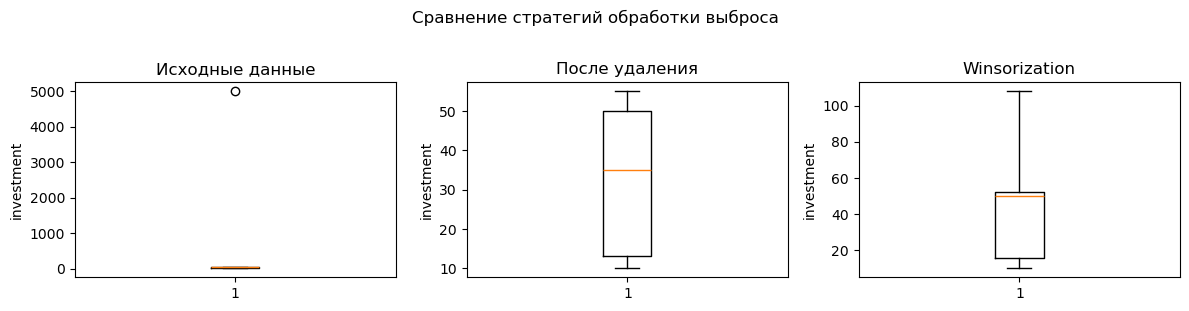

In [ ]:
# Немного забегая вперёд:
# Визуализация: эффект очистки

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].boxplot(invest_series)
axes[0].set_title('Исходные данные')

axes[1].boxplot(invest_removed)
axes[1].set_title('После удаления')

axes[2].boxplot(invest_winsor)
axes[2].set_title('Winsorization')

for ax in axes:
    ax.set_ylabel('investment')

plt.suptitle('Сравнение стратегий обработки выброса', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Сравнение методов обнаружения выбросов

| Метод | Предположение | Когда использовать |
|-------|--------------|-------------------|
| **IQR** | Не требует нормальности | Общий случай, особенно при асимметричных данных |
| **Z-score** | Нормальное распределение | Данные близки к нормальному |
| **Визуальный осмотр** (боксплот, гистограмма) | — | Всегда, в дополнение к численным методам |

> **Золотое правило:** никогда не удаляйте выброс, не посмотрев на него. Иногда выброс — это самое интересное наблюдение в датасете.

---
# Часть II. Визуализация данных

---
## Зачем визуализировать данные?

Числовые сводки (среднее, дисперсия, корреляция) могут быть одинаковыми у совершенно разных наборов данных. Классическая иллюстрация — **квартет Энскомба (1973)**: четыре датасета с практически идентичными статистиками, но принципиально разной структурой, которая видна только на графике.

Задачи визуализации в анализе данных:

| Задача | Тип графика |
|--------|-------------|
| Посмотреть распределение переменной | Гистограмма, боксплот |
| Сравнить группы между собой | Столбчатая диаграмма, боксплот |
| Показать динамику во времени | Линейный график |
| Показать структуру (доли) | Круговая диаграмма, stacked bar |
| Найти связь между двумя переменными | Scatter plot |
| Показать несколько метрик одновременно | Subplots, dashboard |

Визуализация выполняет две разные функции:
- **Exploratory (исследовательская)** — для себя, быстро, чтобы понять данные
- **Explanatory (коммуникационная)** — для аудитории, аккуратно, чтобы донести вывод

---
## 8. Экосистема визуализации в Python

Python имеет богатую и местами конкурирующую экосистему библиотек для визуализации. Важно понимать, что каждая из них занимает свою нишу.

### 8.1 Основные библиотеки

**Matplotlib** — базовый уровень. Большинство остальных библиотек построены поверх него.
- Полный контроль над каждым элементом графика
- Многословный синтаксис для сложных графиков
- Незаменим для публикационного оформления и нестандартных задач

**Seaborn** — статистическая визуализация высокого уровня.
- Построен поверх Matplotlib, читает pandas DataFrame напрямую
- Красивые defaults, встроенные темы
- Специализирован на статистических графиках: violin plot, heatmap, pairplot, регрессионные линии
- Меньше гибкости в тонкой настройке

**Plotly** — интерактивная визуализация.
- Графики с hover, zoom, фильтрами
- Идеален для дашбордов и веб-приложений (Dash)
- Чуть сложнее интегрируется в статичные отчёты

**Altair** — декларативная визуализация на основе Vega-Lite.
- Лаконичный синтаксис, ориентированный на грамматику графики
- Хорошо подходит для исследовательского анализа

**Bokeh** — интерактивность с фокусом на веб.
- Более низкоуровневый, чем Plotly, но более гибкий

### 8.2 Как выбирать

| Сценарий | Рекомендация |
|----------|--------------|
| Быстрый EDA, работа в Jupyter | **Matplotlib** или **Seaborn** |
| Статистические графики (распределения, корреляции) | **Seaborn** |
| Публикация, точный контроль над визуалом | **Matplotlib** |
| Интерактивный дашборд | **Plotly** / **Dash** |
| Вставка в веб-страницу | **Plotly** или **Bokeh** |

> На этом курсе мы работаем с **Matplotlib** — это фундамент, без которого сложно разобраться в любой другой библиотеке.

---
## 9. Архитектура Matplotlib

Понимание внутренней структуры Matplotlib избавляет от большой части путаницы при работе с библиотекой.

### 9.1 Два интерфейса

Matplotlib предоставляет **два способа** рисовать графики:

**Pyplot-интерфейс (`plt.*`)** — процедурный, имитирует MATLAB. Matplotlib отслеживает «текущую ось» за вас. Удобен для быстрых одиночных графиков.

```python
plt.plot(x, y)
plt.title('...')
plt.show()
```

**OO-интерфейс (`fig, ax`)** — объектно-ориентированный. Вы явно работаете с объектами `Figure` и `Axes`. Необходим для сложных компоновок и `subplots`.

```python
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('...')
plt.show()
```

### 9.2 Иерархия объектов

```
Figure  ← весь холст (может содержать несколько Axes)
  └── Axes  ← один график (система координат)
        ├── Axis  ← оси X и Y (деления, метки)
        ├── Title, XLabel, YLabel
        ├── Line2D, Patch, Text  ← визуальные элементы
        └── Legend
```

### 9.3 Разница в методах: Pyplot vs OO

| Pyplot | OO-интерфейс |
|--------|-------------|
| `plt.plot(...)` | `ax.plot(...)` |
| `plt.title('...')` | `ax.set_title('...')` |
| `plt.xlabel('...')` | `ax.set_xlabel('...')` |
| `plt.ylabel('...')` | `ax.set_ylabel('...')` |
| `plt.legend()` | `ax.legend()` |
| `plt.grid(...)` | `ax.grid(...)` |
| `plt.xlim(...)` | `ax.set_xlim(...)` |

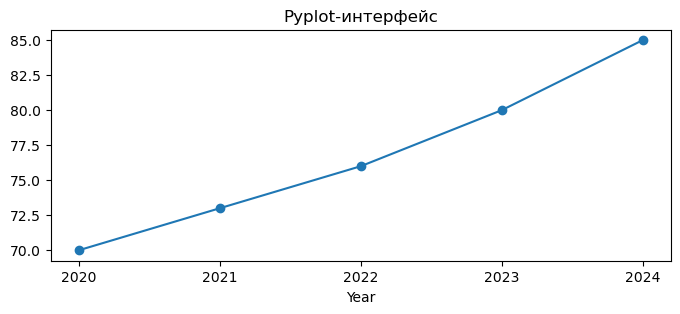

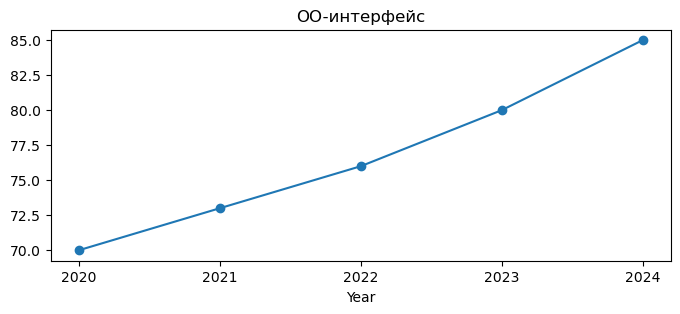

In [ ]:
# Демонстрация: один и тот же результат двумя способами
x = [2020, 2021, 2022, 2023, 2024]
y = [70,   73,   76,   80,   85]

# --- Pyplot-интерфейс ---
plt.figure(figsize=(8, 3))
plt.plot(x, y, 'o-')
plt.title('Pyplot-интерфейс')
plt.xticks(x)
plt.xlabel('Year')
plt.show()

# --- OO-интерфейс ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x, y, 'o-')
ax.set_title('OO-интерфейс')
ax.set_xlabel('Year')
ax.set_xticks(x)
plt.show()

---
## 10. Типы графиков и когда их применять

Выбор типа графика — не эстетическое, а **аналитическое** решение. Неправильный тип может исказить или скрыть закономерность.

| Тип | Назначение | Плохой выбор |
|-----|-----------|-------------|
| **Линейный** | Динамика непрерывной переменной во времени | Категориальные данные без порядка |
| **Столбчатый** | Сравнение значений по категориям | Временные ряды с большим числом точек |
| **Гистограмма** | Распределение числовой переменной | Малое число наблюдений (< 20–30) |
| **Боксплот** | Сравнение распределений нескольких групп | Единственная группа |
| **Круговая диаграмма** | Части одного целого, категорий ≤ 5–6 | Большое число категорий; сравнение нескольких групп |
| **Scatter plot** | Связь между двумя числовыми переменными | Временной ряд |
| **Heatmap** | Матрица значений (корреляции, pivot-таблицы) | — |

> **Практическое правило:** прежде чем строить график, ответьте на вопрос — *что именно я хочу показать?* Ответ определяет тип.

---
## 11. Линейный график

Линейный график подходит для отображения **непрерывного изменения** переменной, как правило — во времени. Ключевое условие: ось X должна иметь смысловой порядок.

### 11.1 Базовый вариант

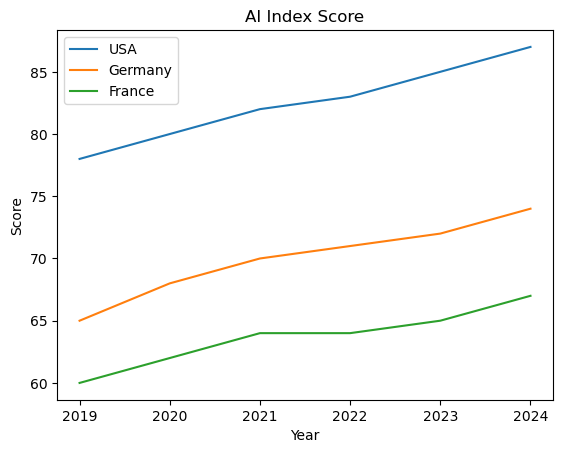

In [ ]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
usa   = [78, 80, 82, 83, 85, 87]
ger   = [65, 68, 70, 71, 72, 74]
fra   = [60, 62, 64, 64, 65, 67]
global_mean = [68, 70, 72, 73, 74, 76]

plt.figure()
plt.plot(years, usa, label='USA')
plt.plot(years, ger, label='Germany')
plt.plot(years, fra, label='France')
plt.legend()
plt.title('AI Index Score')
plt.xlabel('Year')
plt.ylabel('Score')
plt.show()

### 11.2 Публикационный вариант

Добавляем: маркеры на точках, пунктирную линию глобального среднего, увеличенные шрифты, сетку.

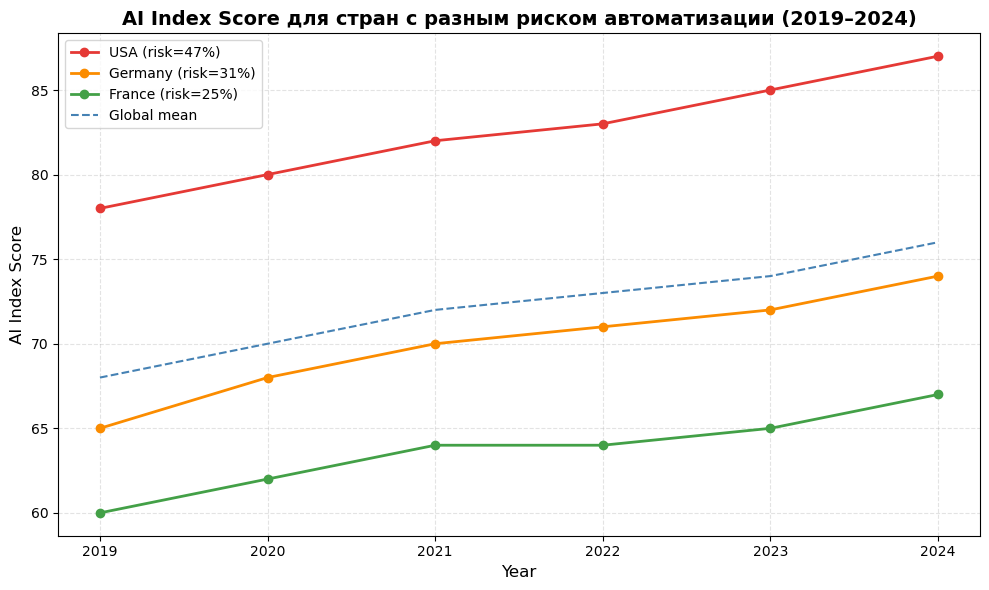

In [ ]:
# Цвета и стиль — задаём явно для воспроизводимости
COLORS = {'high': '#E53935', 'mid': '#FB8C00', 'low': '#43A047'}

plt.figure(figsize=(10, 6))

plt.plot(years, usa, label='USA (risk=47%)',
         color=COLORS['high'], lw=2, marker='o', ms=6)
plt.plot(years, ger, label='Germany (risk=31%)',
         color=COLORS['mid'], lw=2, marker='o', ms=6)
plt.plot(years, fra, label='France (risk=25%)',
         color=COLORS['low'], lw=2, marker='o', ms=6)

# Глобальное среднее — пунктирная линия
plt.plot(years, global_mean, color='steelblue', lw=1.5,
         linestyle='--', label='Global mean')

plt.title('AI Index Score для стран с разным риском автоматизации (2019–2024)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('AI Index Score', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

**Параметры `plt.plot` / `ax.plot`:**

| Параметр | Назначение | Примеры |
|----------|-----------|--------|
| `color` | Цвет линии | `'red'`, `'#E53935'` |
| `lw` / `linewidth` | Толщина линии | `2` |
| `ls` / `linestyle` | Стиль | `'-'` сплошная, `'--'` пунктир, `':'` точки |
| `marker` | Маркер на точках | `'o'` круг, `'s'` квадрат, `'^'` треугольник |
| `ms` / `markersize` | Размер маркера | `6` |
| `label` | Подпись в легенде | `'USA'` |

---
## 12. Столбчатая диаграмма

Столбчатая диаграмма подходит для **сравнения значений по категориям**. Вариант с накоплением (stacked) дополнительно показывает структуру каждого столбца.

Принцип stacked: второй слой рисуется **поверх** первого — для этого передаётся `bottom=` с высотами первого слоя.

### 12.1 Базовый вариант

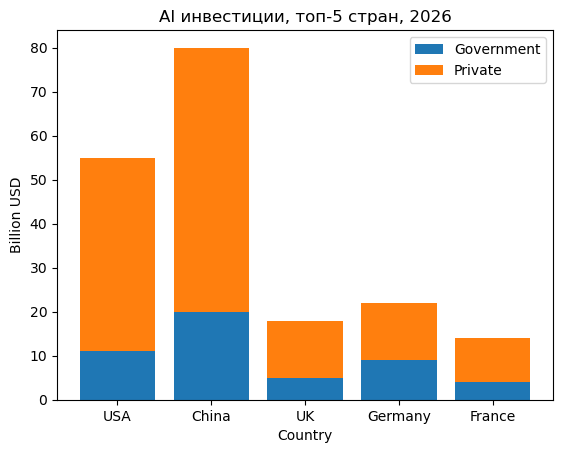

In [ ]:
countries_bar = ['USA', 'China', 'UK', 'Germany', 'France']
gov     = [11.0, 20.0,  5.0,  9.0, 4.0]
total   = [55.0, 80.0, 18.0, 22.0, 14.0]
private = [t - g for t, g in zip(total, gov)]

plt.bar(countries_bar, gov,     label='Government')
plt.bar(countries_bar, private, bottom=gov, label='Private')  # ← bottom!
plt.legend()
plt.title('AI инвестиции, топ-5 стран, 2026')
plt.xlabel('Country')
plt.ylabel('Billion USD')
plt.show()

### 12.2 Публикационный вариант

Добавляем: подписи процентов внутри сегментов, вторую ось (`twinx`) для показа числа стартапов.

**`ax.twinx()`** — создаёт правую ось Y с той же осью X. Позволяет отображать две метрики с разными масштабами на одном графике.

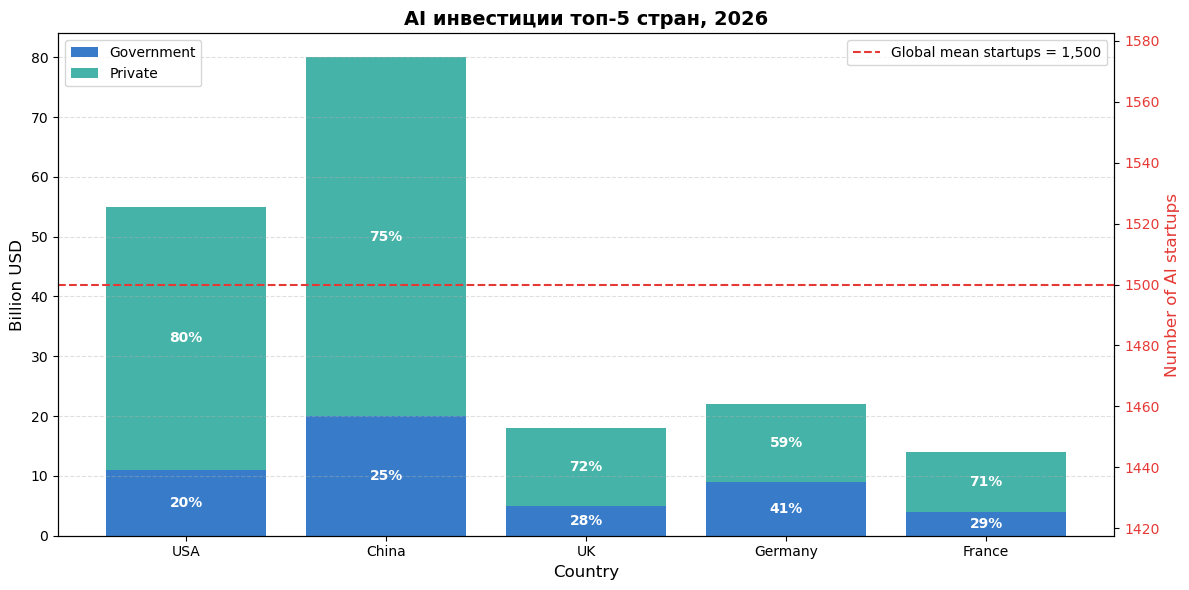

In [ ]:
startups_avg = 1500  # глобальное среднее (демо)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(countries_bar, gov,     label='Government', color='#1565C0', alpha=0.85)
ax.bar(countries_bar, private, bottom=gov, label='Private', color='#26A69A', alpha=0.85)

# Подписи % внутри сегментов
for i, (g, p, t) in enumerate(zip(gov, private, total)):
    ax.text(i, g / 2,     f'{g/t*100:.0f}%',
            ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, g + p / 2, f'{p/t*100:.0f}%',
            ha='center', va='center', color='white', fontweight='bold')

ax.set_title('AI инвестиции топ-5 стран, 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Billion USD', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Вторая ось — правая
ax2 = ax.twinx()
ax2.axhline(startups_avg, color='#E53935', lw=1.5, linestyle='--',
            label=f'Global mean startups = {startups_avg:,}')
ax2.set_ylabel('Number of AI startups', fontsize=12, color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

---
## 13. Круговая диаграмма

Круговая диаграмма показывает **доли одного целого**. Работает хорошо при:
- числе категорий ≤ 5–6
- наличии явного доминирующего сегмента

При большом числе категорий или похожих долях — лучше использовать горизонтальный bar chart.

`plt.pie` возвращает три набора объектов для тонкой настройки:
- **patches** — сами секторы
- **texts** — подписи категорий
- **autotexts** — подписи процентов (при `autopct`)

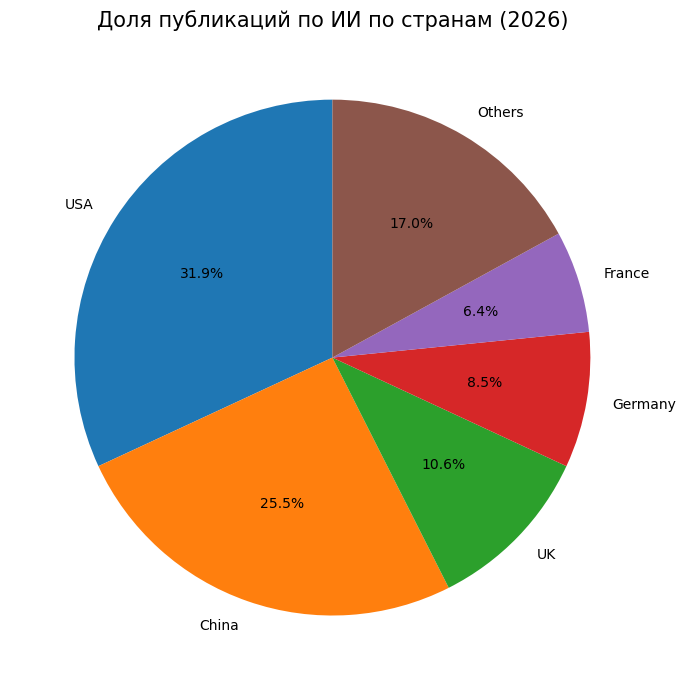

In [ ]:
# Данные: топ-5 + Others
papers = pd.Series({'USA': 15000, 'China': 12000, 'UK': 5000,
                    'Germany': 4000, 'France': 3000, 'Others': 8000})

# Цветовая схема: лидер — акцентный цвет, Others — нейтральный серый
# colors = ['#E53935', '#42A5F5', '#66BB6A', '#FFA726', '#AB47BC', '#BDBDBD']

fig, ax = plt.subplots(figsize=(9, 7))

patches, texts, autotexts = ax.pie(
    papers,
    labels=papers.index,
    autopct='%1.1f%%',
    startangle=90,
    # colors=colors # расскомментируйте, чтобы попробовать задать свои цвета
)

ax.set_title('Доля публикаций по ИИ по странам (2026)', fontsize=15)
plt.tight_layout()
plt.show()

---
## 14. Гистограмма

Гистограмма показывает **распределение** числовой переменной: как часто встречаются значения в каждом интервале (бине).

Гистограмма — не столбчатая диаграмма. Главное отличие: столбцы вплотную (нет разрыва), ось X непрерывна.

**`np.linspace(a, b, n)`** — создаёт `n` равноудалённых границ бинов от `a` до `b`. Это удобнее, чем указывать просто число бинов, — явно контролируешь диапазон.

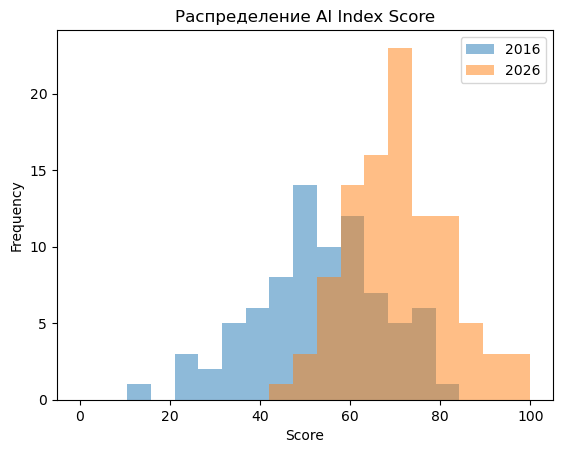

In [ ]:
np.random.seed(42)
scores_2016 = np.random.normal(loc=55, scale=15, size=80).clip(0, 100)
scores_2026 = np.random.normal(loc=70, scale=12, size=100).clip(0, 100)

bins = np.linspace(0, 100, 20)

# Базовый вариант
plt.hist(scores_2016, bins, alpha=0.5, label='2016')
plt.hist(scores_2026, bins, alpha=0.5, label='2026')
plt.legend()
plt.title('Распределение AI Index Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

### `density=True` — нормировка для сравнения выборок разного размера

Без нормировки столбцы большей выборки будут просто выше — это визуально вводит в заблуждение. `density=True` нормирует так, что **площадь под гистограммой равна 1** (плотность вероятности). Теперь сравнение форм распределений корректно.

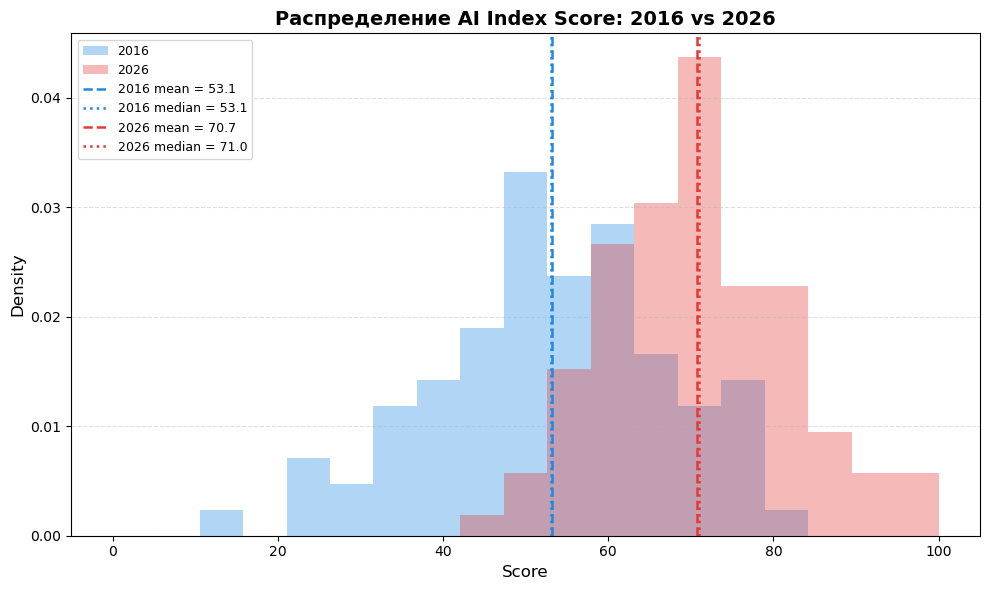

In [ ]:
m16, med16 = scores_2016.mean(), np.median(scores_2016)
m26, med26 = scores_2026.mean(), np.median(scores_2026)

plt.figure(figsize=(10, 6))

plt.hist(scores_2016, bins, alpha=0.35, color='#1E88E5', density=True, label='2016')
plt.hist(scores_2026, bins, alpha=0.35, color='#E53935', density=True, label='2026')

# Вертикальные линии: -- для mean, : для median
plt.axvline(m16,   color='#1E88E5', ls='--', lw=1.8, label=f'2016 mean = {m16:.1f}')
plt.axvline(med16, color='#1E88E5', ls=':',  lw=1.8, label=f'2016 median = {med16:.1f}')
plt.axvline(m26,   color='#E53935', ls='--', lw=1.8, label=f'2026 mean = {m26:.1f}')
plt.axvline(med26, color='#E53935', ls=':',  lw=1.8, label=f'2026 median = {med26:.1f}')

plt.title('Распределение AI Index Score: 2016 vs 2026', fontsize=14, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper left', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Ключевые параметры `plt.hist`:**

| Параметр | Назначение |
|----------|------------|
| `bins` | Число бинов или массив границ |
| `alpha` | Прозрачность — нужна при перекрытии двух гистограмм |
| `density=True` | Нормировка к плотности вероятности |
| `color` | Цвет заливки |

---
## 15. Боксплот

Боксплот (box-and-whisker plot, ящик с усами) — компактная и информативная визуализация распределения. Особенно силён при **сравнении нескольких групп** и автоматически показывает выбросы.

Анатомия боксплота ([Источник](https://datayoga.ru/tpost/6auu3jr63y-boksplot)):


![боксплот](https://static.tildacdn.com/tild6130-3939-4833-b030-303762613530/image.png)

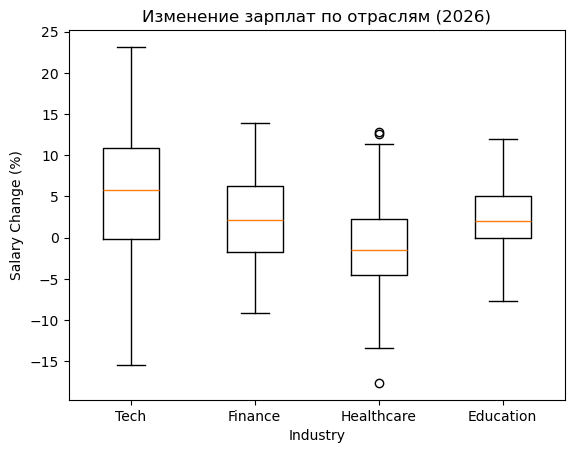

In [ ]:
np.random.seed(0)
industries = ['Tech', 'Finance', 'Healthcare', 'Education']

data_to_plot = [
    np.random.normal( 5,  8, 100),
    np.random.normal( 2,  5, 100),
    np.random.normal(-1,  6, 100),
    np.random.normal( 3,  4, 100),
]

# Базовый вариант
plt.boxplot(data_to_plot, tick_labels=industries)
plt.title('Изменение зарплат по отраслям (2026)')
plt.xlabel('Industry')
plt.ylabel('Salary Change (%)')
plt.show()

**`patch_artist=True`** — обязательный параметр для цветной заливки ящиков. Без него `box.set_facecolor()` не работает.

**`plt.annotate`** с `xycoords='axes fraction'` позиционирует текст в единичных координатах самой оси: `(0, 0)` — нижний левый угол, `(1, 1)` — верхний правый.

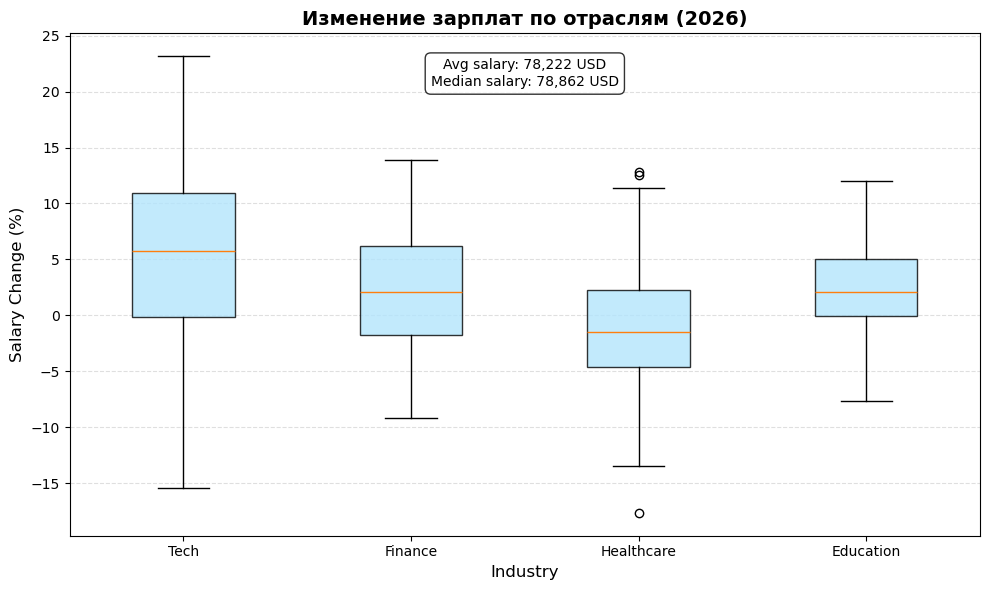

In [ ]:
all_sal = np.concatenate([np.random.normal(80000, 15000, 100) for _ in industries])
mean_sal, median_sal = all_sal.mean(), np.median(all_sal)

plt.figure(figsize=(10, 6))

bp = plt.boxplot(data_to_plot, tick_labels=industries, patch_artist=True)

# Закраска ящиков
for box in bp['boxes']:
    box.set_facecolor('#B3E5FC')
    box.set_alpha(0.8)

# Аннотация с глобальной статистикой зарплат
plt.annotate(
    f'Avg salary: {mean_sal:,.0f} USD\nMedian salary: {median_sal:,.0f} USD',
    xy=(0.5, 0.95),
    xycoords='axes fraction',
    ha='center', va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.4')
)

plt.title('Изменение зарплат по отраслям (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Salary Change (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 16. Несколько графиков: `subplots`

`plt.subplots(rows, cols)` создаёт **фигуру с сеткой графиков**. Это стандартный способ собрать несколько визуализаций в один аналитический дашборд.

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 строка, 3 столбца → axes[0..2]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2×2 → axes[0,0] ... axes[1,1]
```

При нескольких графиках обязательно использовать **OO-интерфейс** (`ax.method()`), иначе все вызовы `plt.*` будут влиять только на последний активный график.

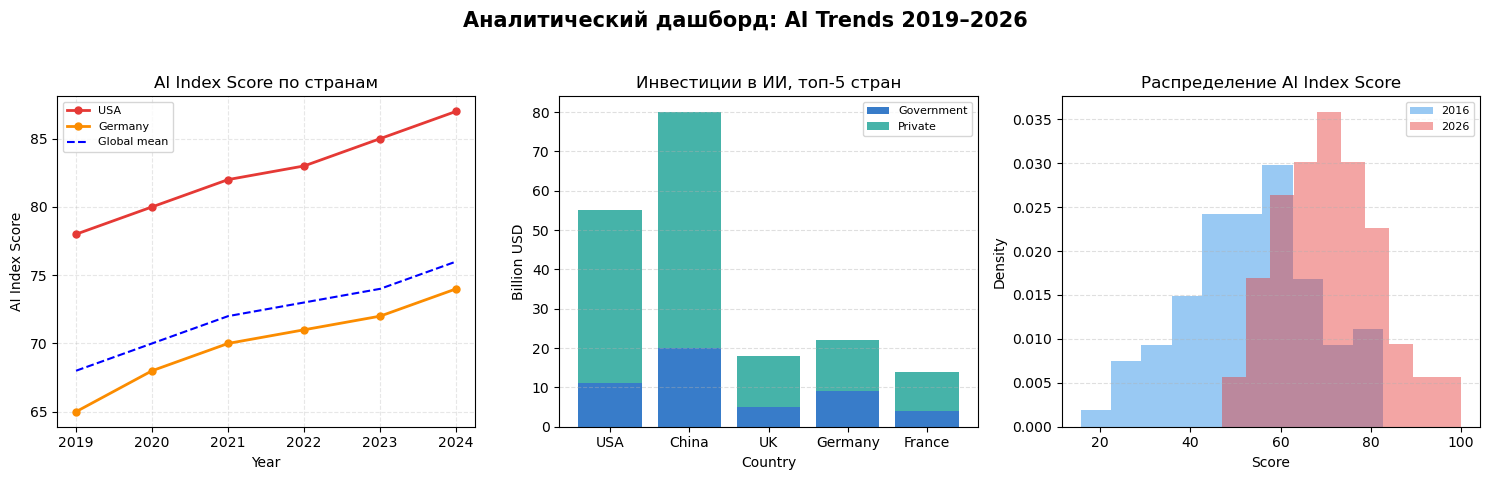

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- График 1: линейный ---
axes[0].plot(years, usa,  color='#E53935', lw=2, marker='o', ms=5, label='USA')
axes[0].plot(years, ger,  color='#FB8C00', lw=2, marker='o', ms=5, label='Germany')
axes[0].plot(years, global_mean, 'b--', lw=1.5, label='Global mean')
axes[0].set_title('AI Index Score по странам')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('AI Index Score')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

# --- График 2: stacked bar ---
axes[1].bar(countries_bar, gov,     label='Government', color='#1565C0', alpha=0.85)
axes[1].bar(countries_bar, private, bottom=gov, label='Private', color='#26A69A', alpha=0.85)
axes[1].set_title('Инвестиции в ИИ, топ-5 стран')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Billion USD')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# --- График 3: гистограмма ---
axes[2].hist(scores_2016, bins=10, alpha=0.45, color='#1E88E5', density=True, label='2016')
axes[2].hist(scores_2026, bins=10, alpha=0.45, color='#E53935', density=True, label='2026')
axes[2].set_title('Распределение AI Index Score')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

# Общий заголовок фигуры
fig.suptitle('Аналитический дашборд: AI Trends 2019–2026',
             fontsize=15, fontweight='bold')

# rect=[left, bottom, right, top] — оставляет место под suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

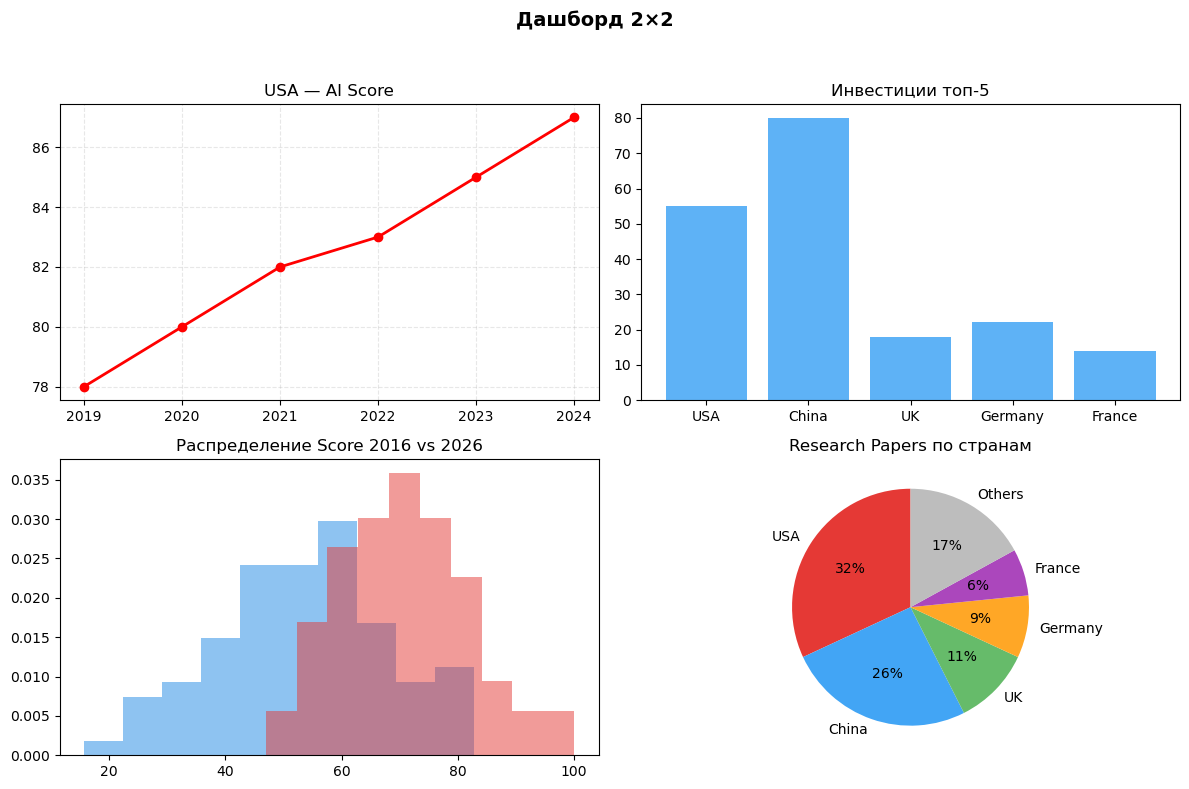

In [ ]:
# Сетка 2×2: axes[строка, столбец]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(years, usa, 'r-o', lw=2)
axes[0, 0].set_title('USA — AI Score')
axes[0, 0].grid(linestyle='--', alpha=0.3)

axes[0, 1].bar(countries_bar, total, color='#42A5F5', alpha=0.85)
axes[0, 1].set_title('Инвестиции топ-5')

axes[1, 0].hist(scores_2016, bins=10, color='#1E88E5', alpha=0.5, density=True)
axes[1, 0].hist(scores_2026, bins=10, color='#E53935', alpha=0.5, density=True)
axes[1, 0].set_title('Распределение Score 2016 vs 2026')

axes[1, 1].pie(papers, labels=papers.index, autopct='%1.0f%%',
               startangle=90, colors=colors)
axes[1, 1].set_title('Research Papers по странам')

fig.suptitle('Дашборд 2×2', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## 17. Принципы хорошей визуализации

Технические навыки — необходимое, но не достаточное условие. Хорошая визуализация строится на принципах, которые применяются в научных публикациях, медиа и бизнес-аналитике.

### 17.1 Принципы Эдварда Тафти

Эдвард Тафти — один из ключевых теоретиков визуализации данных. Его главные идеи:

- **Data-ink ratio**: максимум информации на минимум чернил. Убирайте всё, что не несёт смысловой нагрузки — лишние рамки, сетки, тени, 3D-эффекты
- **Chart junk**: декоративные элементы, отвлекающие от данных
- **Small multiples**: одни и те же графики для разных подгрупп — более честное сравнение, чем одна сложная фигура

### 17.2 Практические правила

**Заголовок и подписи:**
- Заголовок формулирует **вывод**, а не описывает данные.
- Все оси должны быть подписаны, единицы измерения указаны

**Цвет:**
- Используйте цвет для передачи смысла, а не для украшения
- Не более 5–7 разных цветов на одном графике
- Проверьте читаемость при печати в оттенках серого
- Учитывайте дальтонизм: избегайте пар «красный — зелёный» без дополнительного кодирования

**Шкала:**
- Ось Y должна начинаться с нуля для столбчатых диаграмм (обрезанная шкала преувеличивает различия)
- Для линейных графиков начало с нуля не всегда обязательно — важен контекст

**Легенда:**
- Легенда удобна, но ещё лучше — подпись прямо у линии (direct labeling)

### 17.3 Шпаргалка по оформлению в Matplotlib

**Сводная таблица элементов оформления:**

| Элемент | Метод | Ключевые параметры |
|---------|-------|--------------------|
| Заголовок | `ax.set_title(...)` | `fontsize`, `fontweight='bold'`, `pad` |
| Подпись оси | `ax.set_xlabel/ylabel(...)` | `fontsize` |
| Легенда | `ax.legend(...)` | `fontsize`, `loc`, `framealpha` |
| Сетка | `ax.grid(...)` | `linestyle`, `alpha`, `axis='y'` |
| Убрать рамку | `ax.spines['top'].set_visible(False)` | `'top'`, `'right'` |
| Размер фигуры | `plt.subplots(figsize=(w, h))` | дюймы |
| Общий заголовок | `fig.suptitle(...)` | `fontsize`, `fontweight` |
| Отступы | `plt.tight_layout(rect=[l, b, r, t])` | место под suptitle |
| Горизонт. линия | `ax.axhline(y, ...)` | `color`, `ls`, `lw`, `label` |
| Аннотация | `ax.annotate(text, xy=, xycoords=, bbox=)` | `xycoords='axes fraction'` |
| Правая ось Y | `ax2 = ax.twinx()` | — |

**Позиции легенды:** `'upper left'`, `'upper center'`, `'upper right'`, `'center left'`, `'lower right'` и др.

---
## Итоговая шпаргалка

```python
# ── Диагностика качества данных ──────────────────────────────────────────────
df.isna().sum()                                     # пропуски: количество
(df.isna().sum() / len(df) * 100).round(1)          # пропуски: доля в %
df.describe()                                       # распределение числовых
df.dtypes                                           # типы (object → проверить)
df.duplicated().sum()                               # полные дубликаты
df.drop_duplicates(inplace=True)                    # удалить дубликаты

# ── Очистка: типы и ошибочные значения ───────────────────────────────────────
pd.to_numeric(df['col'], errors='coerce')           # строки → NaN
df['col'].replace(['Unknown', 'error'], np.nan)     # явная замена
df['col'].str.strip().str.lower()                   # нормализация строк

# ── Очистка: пропуски ────────────────────────────────────────────────────────
df.dropna(subset=['col'])                           # удалить строки с NaN
df['col'].fillna(df['col'].median())                # заполнить медианой
df['col'].interpolate(method='linear')              # интерполяция ряда
df.drop(columns=['col'])                            # удалить столбец

# ── Очистка: выбросы (IQR) ───────────────────────────────────────────────────
Q1, Q3 = df['col'].quantile(0.25), df['col'].quantile(0.75)
IQR = Q3 - Q1
mask = (df['col'] >= Q1 - 1.5*IQR) & (df['col'] <= Q3 + 1.5*IQR)
df['col'].where(mask, other=np.nan)                 # замена на NaN
df['col'].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR) # winsorization

# ── Типы графиков ────────────────────────────────────────────────────────────
plt.plot(x, y, color=, lw=, ls=, marker=, ms=, label=)   # линейный
plt.bar(x, y, bottom=, color=, alpha=, label=)            # столбчатый
plt.pie(vals, labels=, autopct=, colors=)                 # круговой
plt.hist(data, bins=, alpha=, density=True, color=)       # гистограмма
plt.boxplot(list_of_arrays, tick_labels=, patch_artist=True)
np.linspace(0, 100, 20)                                   # равномерные бины

# ── Subplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1D: axes[i]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2D: axes[i, j]
# OO-интерфейс: ax.plot(), ax.set_title(), ax.set_xlabel(), ax.legend()
fig.suptitle('Заголовок', fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ── Дополнительные элементы ───────────────────────────────────────────────────
ax2 = ax.twinx()                                    # правая ось Y
ax.axhline(y, color=, ls=, lw=, label=)             # горизонтальная линия
ax.annotate(text, xy=(0.5,0.95), xycoords='axes fraction',
            ha='center', va='top', bbox=dict(boxstyle='round', facecolor='white'))
patches, texts, autotexts = ax.pie(...)             # объекты pie для настройки
for box in bp['boxes']: box.set_facecolor(...)      # цвет ящиков боксплота
ax.spines['top'].set_visible(False)                 # убрать рамку
```

---

**Полезные ресурсы:**
- [Matplotlib документация](https://matplotlib.org/stable/)
- [Seaborn документация](https://seaborn.pydata.org/)
- [Plotly документация](https://plotly.com/python/)
- [Python Graph Gallery](https://python-graph-gallery.com/) — примеры всех типов графиков
- [From Data to Viz](https://www.data-to-viz.com/) — выбор правильного типа графика
- Edward Tufte, *The Visual Display of Quantitative Information* (2001)

---
## 🎁 Бонус: стиль xkcd

`plt.xkcd()` — встроенный в Matplotlib стиль, имитирующий рисовки из комикса [xkcd](https://xkcd.com/) Рэндалла Манро.
Линии становятся «дрожащими», шрифт — рукописным, весь вид — намеренно небрежным.

**Зачем это нужно серьёзному аналитику?** Это просто весело. Ну и комиксы эти - легендарные.

Стиль включается как контекстный менеджер (`with plt.xkcd():`), поэтому **не влияет** на остальные графики в ноутбуке.

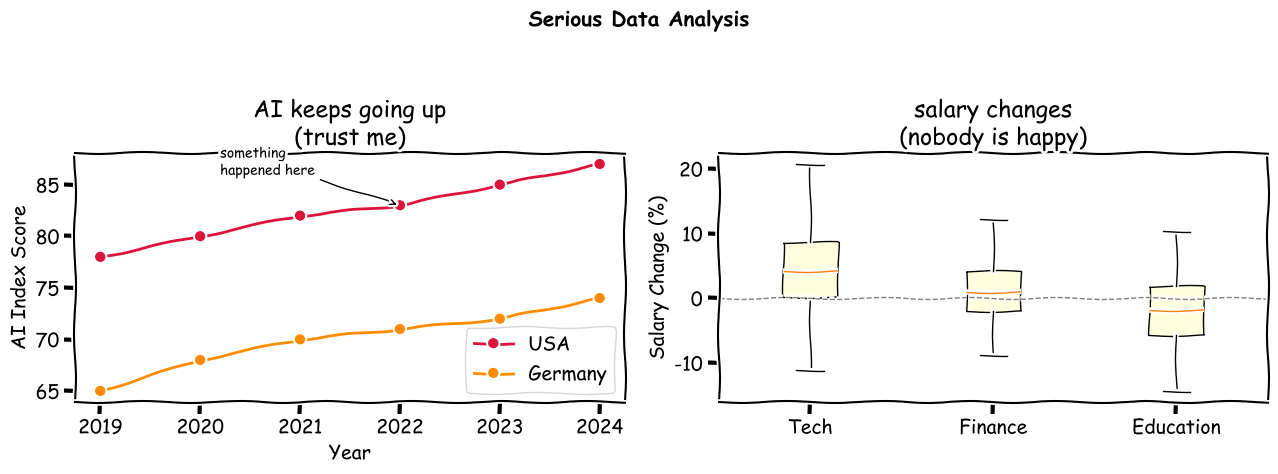

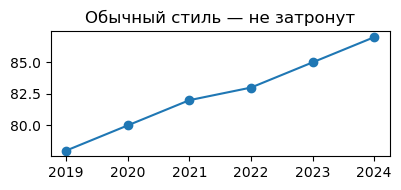

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.set_loglevel("CRITICAL")

years = [2019, 2020, 2021, 2022, 2023, 2024]
usa   = [78, 80, 82, 83, 85, 87]
ger   = [65, 68, 70, 71, 72, 74]

# with plt.xkcd() — стиль действует только внутри блока
with plt.xkcd():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- Линейный ---
    axes[0].plot(years, usa, 'o-', color='crimson',    lw=2, label='USA')
    axes[0].plot(years, ger, 'o-', color='darkorange', lw=2, label='Germany')
    axes[0].set_title('AI keeps going up\n(trust me)')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('AI Index Score')
    axes[0].legend()
    axes[0].annotate(
        'something\nhappened here',
        xy=(2022, 83), xytext=(2020.2, 86),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=10
    )

    # --- Боксплот ---
    np.random.seed(7)
    data = [
        np.random.normal(5,  7, 80),
        np.random.normal(1,  5, 80),
        np.random.normal(-2, 6, 80),
    ]
    axes[1].boxplot(data, tick_labels=['Tech', 'Finance', 'Education'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightyellow'))
    axes[1].set_title('salary changes\n(nobody is happy)')
    axes[1].set_ylabel('Salary Change (%)')
    axes[1].axhline(0, color='grey', lw=1, linestyle='--')

    fig.suptitle('Serious Data Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

# За пределами with — обычный стиль возвращается
plt.figure(figsize=(4, 2))
plt.plot(years, usa, 'o-')
plt.title('Обычный стиль — не затронут')
plt.tight_layout()
plt.show()